# Data Exploration

This notebook performs basic exploratory data analysis on the final dataset produced during feature engineering.

The aim is to perform simple sanity checks and gain an initial understanding of the data before building predictive models.

The analysis includes:
- inspecting the dataset structure
- checking for missing or infinite values
- examining summary statistics
- visualising distributions of key features

In [1]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [ ]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\processed\\final_dataset_40k_feature_transform.parquet"
)
#files_final = glob.glob(
#    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\processed\\final_dataset.parquet"
#)
final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

final_dataset.reset_index(drop=True,inplace=True)
final_dataset.dropna(inplace=True) # stitching effects

## Look at the prediction target

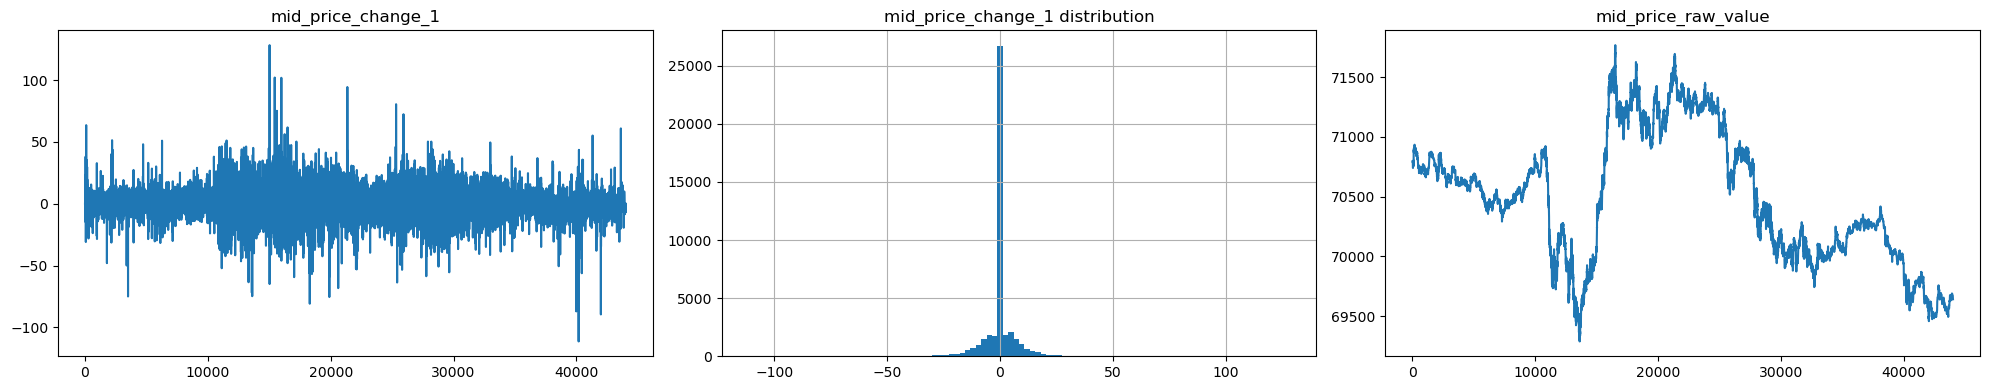

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(20, 4))

final_dataset["mid_price_change_1"].plot(ax=ax[0], title="mid_price_change_1")
final_dataset["mid_price_change_1"].hist(ax=ax[1], bins=100)
final_dataset["mid_price"].plot(ax=ax[2], title="mid_price_raw_value")

ax[1].set_title("mid_price_change_1 distribution")
plt.tight_layout()
plt.show()

### Target Exploration

The mid-price change fluctuates around **zero** with mostly small movements and occasional large spikes, corresponding to bursts of volatility.

The distribution is **strongly centred at zero** with a large spike at zero, meaning the mid-price often does not change between snapshots. The tails are heavier than Gaussian, with a slightly stronger right tail.

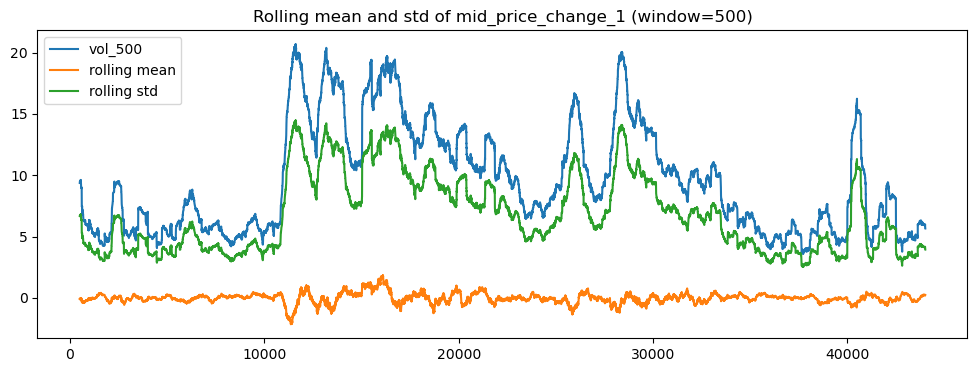

In [4]:
window = 500

rolling_mean = final_dataset["mid_price_change_1"].rolling(window).mean()
rolling_std = final_dataset["mid_price_change_1"].rolling(window).std()
fig, ax = plt.subplots(1, 1, figsize=(12, 4))


vol = final_dataset["log_return_1"].rolling(window).std() * 100000
vol.plot(ax=ax, label="vol_500")
rolling_mean.plot(ax=ax, label="rolling mean")
rolling_std.plot(ax=ax, label="rolling std")

ax.set_title(f"Rolling mean and std of mid_price_change_1 (window={window})")
ax.legend()

plt.show()

- Plotting rolling window std of the mid_price_change shows generally a constant std of the mid_price_change until we get to 2500s where it blows up for a period of time (maybe be useful for regime models)
- the mean is roughly zero which is good no persistent drift

Look at autocorrelation of the mid_price_change

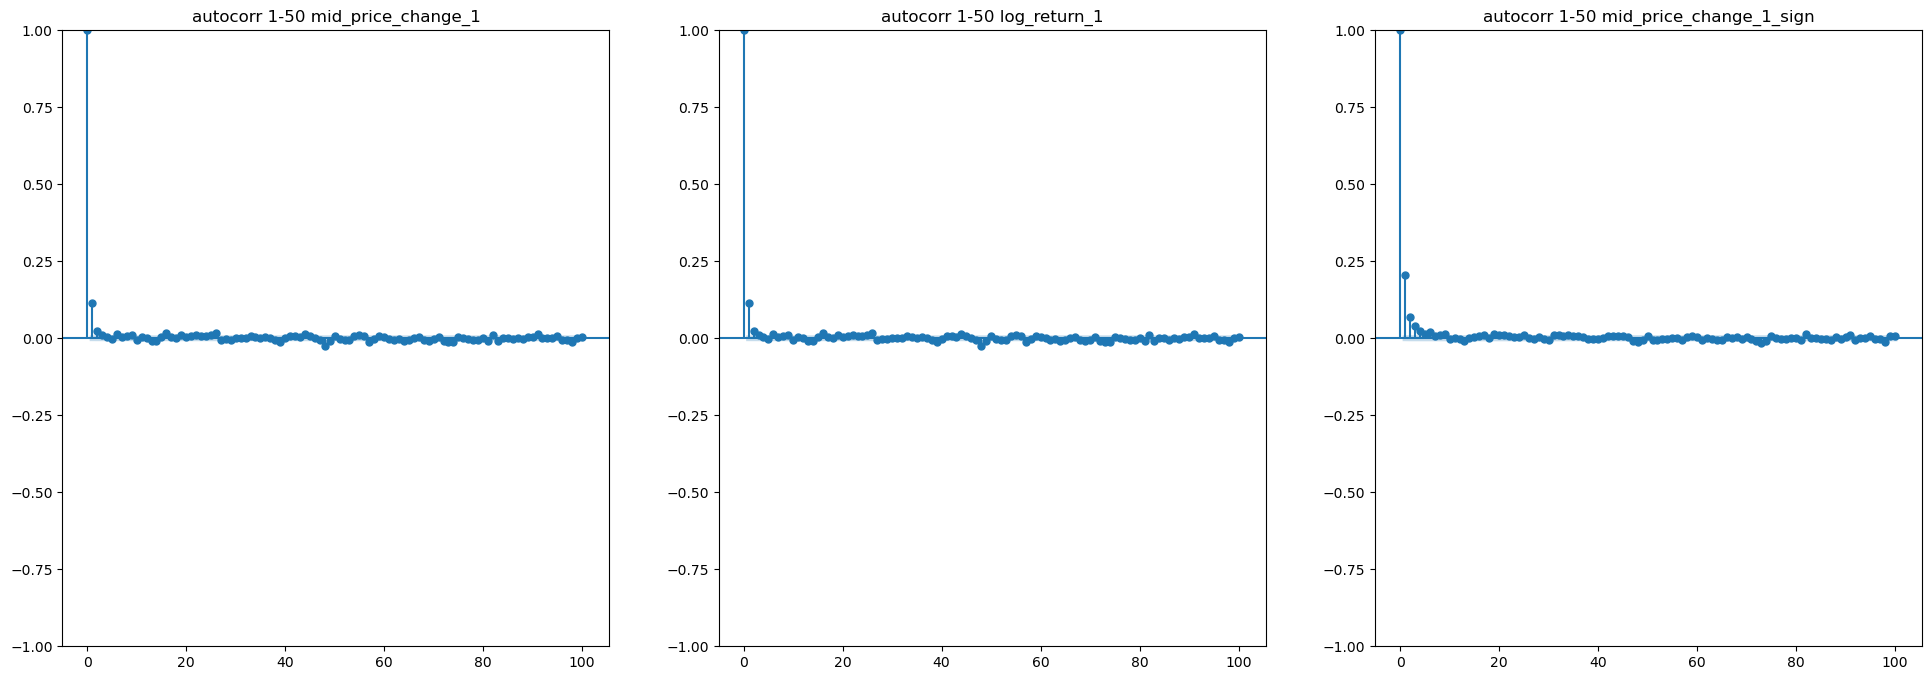

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(1, 3, figsize=(24, 8))


plot_acf(
    final_dataset["mid_price_change_1"],
    ax=ax[0],
    title="autocorr 1-50 mid_price_change_1",
    lags=100,
)
plot_acf(
    final_dataset["log_return_1"],
    ax=ax[1],
    title="autocorr 1-50 log_return_1",
    lags=100,
)
plot_acf(
    final_dataset["mid_price_change_1_sign"],
    ax=ax[2],
    title="autocorr 1-50 mid_price_change_1_sign",
    lags=100,
)


plt.show()

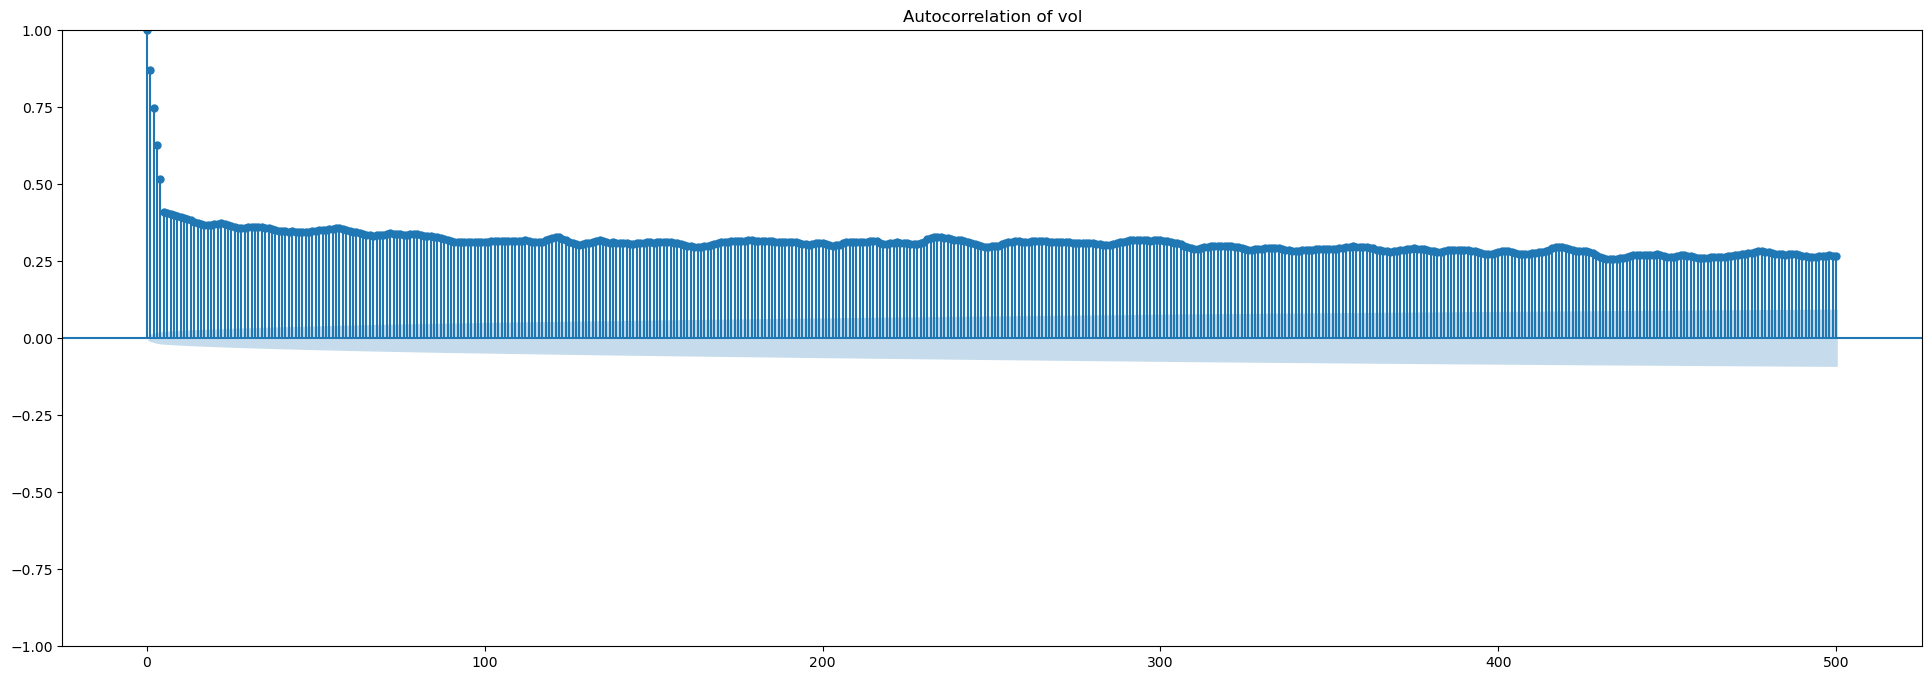

In [6]:
# Volatility regimes
fig, ax = plt.subplots(1, 1, figsize=(24, 8))

vol = final_dataset["vol_5"]

plot_acf(vol, ax=ax, lags=500)
plt.title("Autocorrelation of vol")
plt.show()

Can see volitlity is very autocorrelated with nearby volility, the peaking periodic structure comes from the fact that vol_5 has overlapping measurements

Price changes and log returns show almost no autocorrelation, meaning past moves do not strongly predict future ones. 

However, the sign of the price change shows some short-lag autocorrelation, suggesting smals runs where moves in the same direction can occur for a few steps.

# Checking random walk assumption holds nt

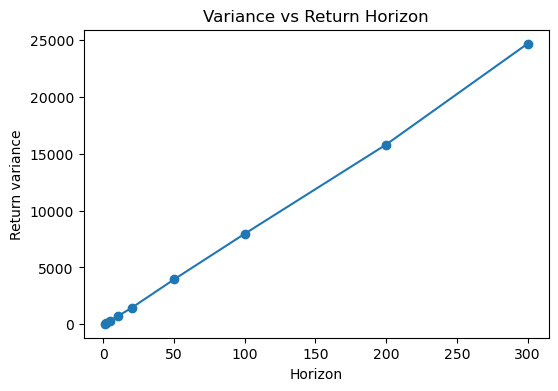

In [7]:
n_walk = [1, 2, 5, 10, 20, 50, 100, 200, 300]

variances = []

for val in n_walk:
    r = final_dataset["mid_price"].diff(val)
    variances.append(r.var())

plt.figure(figsize=(6, 4))
plt.plot(n_walk, variances, marker="o")
# plt.xscale("log")
plt.xlabel("Horizon")
plt.ylabel("Return variance")
plt.title("Variance vs Return Horizon")

plt.show()

# class imbalance

In [8]:
final_dataset["mid_price_change_1_sign"].value_counts(normalize=True)

mid_price_change_1_sign
 0.0    0.573036
 1.0    0.217550
-1.0    0.209414
Name: proportion, dtype: float64

### Class Imbalance

There is class imbalance so we need to be careful during future training, as the model could focus too much on the majority class.

An interesting observation is that even though we see **more down ticks than up ticks**, the overall price is still increasing.

This implies that the **upward moves are larger in magnitude**, meaning that a few bigger upward ticks cause the overall price drift rather than many small changes accumulating.

In [9]:
final_dataset.groupby("mid_price_change_1_sign")["mid_price_change_1"].mean()

mid_price_change_1_sign
-1.0   -8.555163
 0.0    0.000000
 1.0    8.114653
Name: mid_price_change_1, dtype: float64

In [10]:
final_dataset["imbalance_1"].mean()

np.float64(0.029238843256626398)

The average order book imbalance across the dataset is close to zero (slightly negative).

This suggests there is **no strong persistent imbalance in the order book overall**.

Therefore the overall price increase is likely **not caused by a constant imbalance**, but possibly by behaviour at specific moments where the imbalance becomes large.

# looking at features

In [11]:
final_dataset.keys()

Index(['timestamp', 'lob_bids_price_1', 'lob_bids_price_2', 'lob_bids_price_3',
       'lob_bids_price_4', 'lob_bids_price_5', 'lob_bids_price_6',
       'lob_bids_price_7', 'lob_bids_price_8', 'lob_bids_price_9',
       ...
       'std_trade_size', 'vwap', 'max_over_average', 'trade_volume_imbalance',
       'trade_volume_change', 'trade_count_change',
       'lag_trade_volume_imbalance_1', 'lag_trade_volume_imbalance_2',
       'lag_trade_volume_imbalance_3', 'lag_trade_volume_imbalance_5'],
      dtype='str', length=113)

<Axes: title={'center': 'imbalance_1'}>

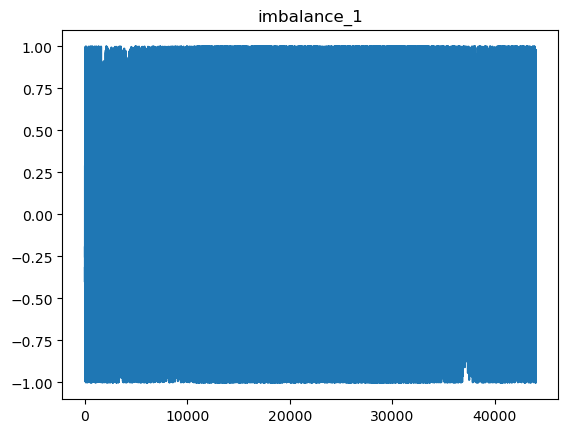

In [12]:
final_dataset["imbalance_1"].plot(title="imbalance_1")

In [13]:
def plotter_features(final_dataset, cols):
    # numeric_cols = final_dataset.select_dtypes(include="number").columns

    for col in cols:

        fig = plt.figure(figsize=(24, 8))
        gs = fig.add_gridspec(2, 4)

        ax = [
            fig.add_subplot(gs[0, 0]),  # ax[0]
            fig.add_subplot(gs[0, 1]),  # ax[1]
            fig.add_subplot(gs[0, 2]),  # ax[2]
            fig.add_subplot(gs[1, :]),  # ax[3] (wide bottom)
            fig.add_subplot(gs[0, 3]),  # ax[4]
        ]
        # time series
        final_dataset[col].plot(ax=ax[0])
        ax[0].set_title(f"{col} over time")

        # histogram with clipping
        clipped = final_dataset[col].clip(
            final_dataset[col].quantile(0.01), final_dataset[col].quantile(0.99)
        )

        clipped.hist(ax=ax[1], bins=100)

        ax[1].set_title(f"{col} distribution (1–99% clipped)")

        # boxplot
        ax[2].boxplot(final_dataset[col], vert=True)
        ax[2].set_title(f"{col} boxplot")

        plot_acf(final_dataset[col].dropna(), ax=ax[3], lags=100)
        ax[3].set_title(f"{col} autocorrelation")
        ax[3].ticklabel_format(style="plain", axis="y")
        s = final_dataset[col]

        stats = (
            f"mean: {s.mean():.2e}\n"
            f"std: {s.std():.2e}\n"
            f"min: {s.min():.2e}\n"
            f"q25: {s.quantile(0.25):.2e}\n"
            f"q50: {s.quantile(0.50):.2e}\n"
            f"q75: {s.quantile(0.75):.2e}\n"
            f"max: {s.max():.2e}\n\n"
            f"top:\n{s.round(8).value_counts().head(5)}"
        )

        ax[4].axis("off")
        ax[4].text(0, 1, stats, va="top", family="monospace")

        plt.tight_layout()
        plt.show()

In [14]:
lob_features = [
    "lob_bids_price_1",
    "lob_bids_price_2",
    "lob_bids_price_3",
    "lob_bids_price_4",
    "lob_bids_price_5",
    "lob_bids_price_6",
    "lob_bids_price_7",
    "lob_bids_price_8",
    "lob_bids_price_9",
    "lob_bids_price_10",
    "lob_bids_volume_1",
    "lob_bids_volume_2",
    "lob_bids_volume_3",
    "lob_bids_volume_4",
    "lob_bids_volume_5",
    "lob_bids_volume_6",
    "lob_bids_volume_7",
    "lob_bids_volume_8",
    "lob_bids_volume_9",
    "lob_bids_volume_10",
    "lob_asks_price_1",
    "lob_asks_price_2",
    "lob_asks_price_3",
    "lob_asks_price_4",
    "lob_asks_price_5",
    "lob_asks_price_6",
    "lob_asks_price_7",
    "lob_asks_price_8",
    "lob_asks_price_9",
    "lob_asks_price_10",
    "lob_asks_volume_1",
    "lob_asks_volume_2",
    "lob_asks_volume_3",
    "lob_asks_volume_4",
    "lob_asks_volume_5",
    "lob_asks_volume_6",
    "lob_asks_volume_7",
    "lob_asks_volume_8",
    "lob_asks_volume_9",
    "lob_asks_volume_10",
    "log_depth_ratio_2",
    "log_depth_ratio_3",
    "log_depth_ratio_4",
    "log_depth_ratio_5",
    "log_depth_ratio_6",
    "log_depth_ratio_7",
    "log_depth_ratio_8",
    "log_depth_ratio_9",
    "log_depth_ratio_10",
]

spread_features = ["rel_spread", "spread"]
imbalance_features = [
    "imbalance_1",
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_1",
    "imbalance_depth_2",
    "imbalance_depth_3",
    "imbalance_depth_4",
    "imbalance_depth_5",
    "imbalance_depth_6",
    "imbalance_depth_7",
    "imbalance_depth_8",
    "imbalance_depth_9",
    "imbalance_depth_10",
]
liquidity_features = [
    "liquidity",
    "total_bid_volume_10",
    "total_ask_volume_10",
    "total_book_volume",
    "max_bid_ask_vol_ratio",
]
microprice_features = [
    "microprice",
    "microprice_change",
    "mid_minus_micro",
    "microprice_weighted_10",
]
return_features = [
    "return_1",
    "return_5",
    "log_return_1",
    "log_return_2",
    "log_return_3",
    "log_return_5",
    "log_return_20",
    "mid_price_change_1",
    "mid_price_change_5",
    "mid_price_change_20",
]
momentum_features = [
    "momentum_5_log_return_1",
    "momentum_20_log_return_1",
]
volatility_features = [
    "vol_5",
    "vol_20",
    "realized_vol_5",
    "realized_vol_20",
]
trade_activity_features = [
    "trade_count",
        "buy_count",
            "sell_count",
]
trade_volume_features = [
    "total_trade_volume",
    "buy_volume",
    "sell_volume",
    "avg_trade_size",
    "max_trade_size",
    "min_trade_size",
    "std_trade_size",
    "max_over_average",
]
trade_flow_features = [
    "trade_volume_imbalance",
]
trade_dynamics_features = [
    "trade_volume_change",
    "trade_count_change",
]
lagged_trade_features = [
    "lag_trade_volume_imbalance_1",
    "lag_trade_volume_imbalance_2",
    "lag_trade_volume_imbalance_3",
    "lag_trade_volume_imbalance_5",
]
feature_groups = {
    "lob_features": lob_features,
    "spread": spread_features,
    "imbalance": imbalance_features,
    "liquidity": liquidity_features,
    "microprice": microprice_features,
    "returns": return_features,
    "momentum": momentum_features,
    "volatility": volatility_features,
    "trade_activity": trade_activity_features,
    "trade_volume": trade_volume_features,
    "trade_flow": trade_flow_features,
    "trade_dynamics": trade_dynamics_features,
    "lagged_trade": lagged_trade_features,
}

In [15]:
# plotter_features(final_dataset, feature_groups["lob_features"])

In [16]:
# plotter_features(final_dataset, feature_groups["spread"])

### Spread Behaviour

- Spread and relative spread are very small and stable most of the time.
- Values are concentrated at the minimum tick size(0.01)
- There are occasional spikes that also correspond to the different volatility regime as shown earlier
- no autocorr

In [17]:
# plotter_features(final_dataset, feature_groups["imbalance"])

### Order Book Imbalance

- Imbalance fluctuates rapidly between −1 and 1 over time.
- The distribution is wide, indicating frequent shifts between bid and ask dominance.
- mean is slightly negative
- strong short autocorr short memory

In [18]:
# plotter_features(final_dataset, feature_groups["liquidity"])

### Order Book Liquidity

- Liquidity and book volumes are generally stable with occasional spikes.
- Distributions are right-skewed, indicating most observations are small with rare large bursts.
- Volume ratio shows extreme outliers, suggesting temporary strong imbalance on one side of the book (also general feature of single ratio vars)

In [19]:
# plotter_features(final_dataset, feature_groups["microprice"])

### Microprice Features

- Microprice follows the overall price trend and moves smoothly over time.
- Microprice changes are centred around zero with occasional large spikes.
- The difference between mid price and microprice is usually small, indicating balanced order book pressure most of the time
- The spikes also generally occur at the same time volatility regime change occurs
-  price change is not autocorrelated

In [20]:
# plotter_features(final_dataset, feature_groups["returns"])

### Returns

- Returns are centred around zero with most observations very close to zero.
- The distributions are roughly symmetric with occasional large spikes.
- Volatility appears clustered, with periods of higher return fluctuations.
- returns over bigger steps are autocorr because of overlapping values used 

In [21]:
# plotter_features(final_dataset, feature_groups["momentum"])

### Momentum

- Momentum values are centred around zero with small fluctuations.
- Most observations are very close to zero
- Occasional spikes occur in short bursts
- same autocorr behaviour as return

In [22]:
# plotter_features(final_dataset, feature_groups["volatility"])

### Volatility

- Volatility remains low most of the time with occasional sharp spikes.
- These spikes align with the same periods as other locations
- vol clustering means autocorr
  

In [23]:
# plotter_features(final_dataset, feature_groups["trade_activity"])

### Trade Activity

- Trade counts fluctuate significantly over time with occasional bursts of activity.
- Distributions have long tails
- minimal autocorr, usually 1 step after ~ most likely due to trades taking more than 1 second to fully complete

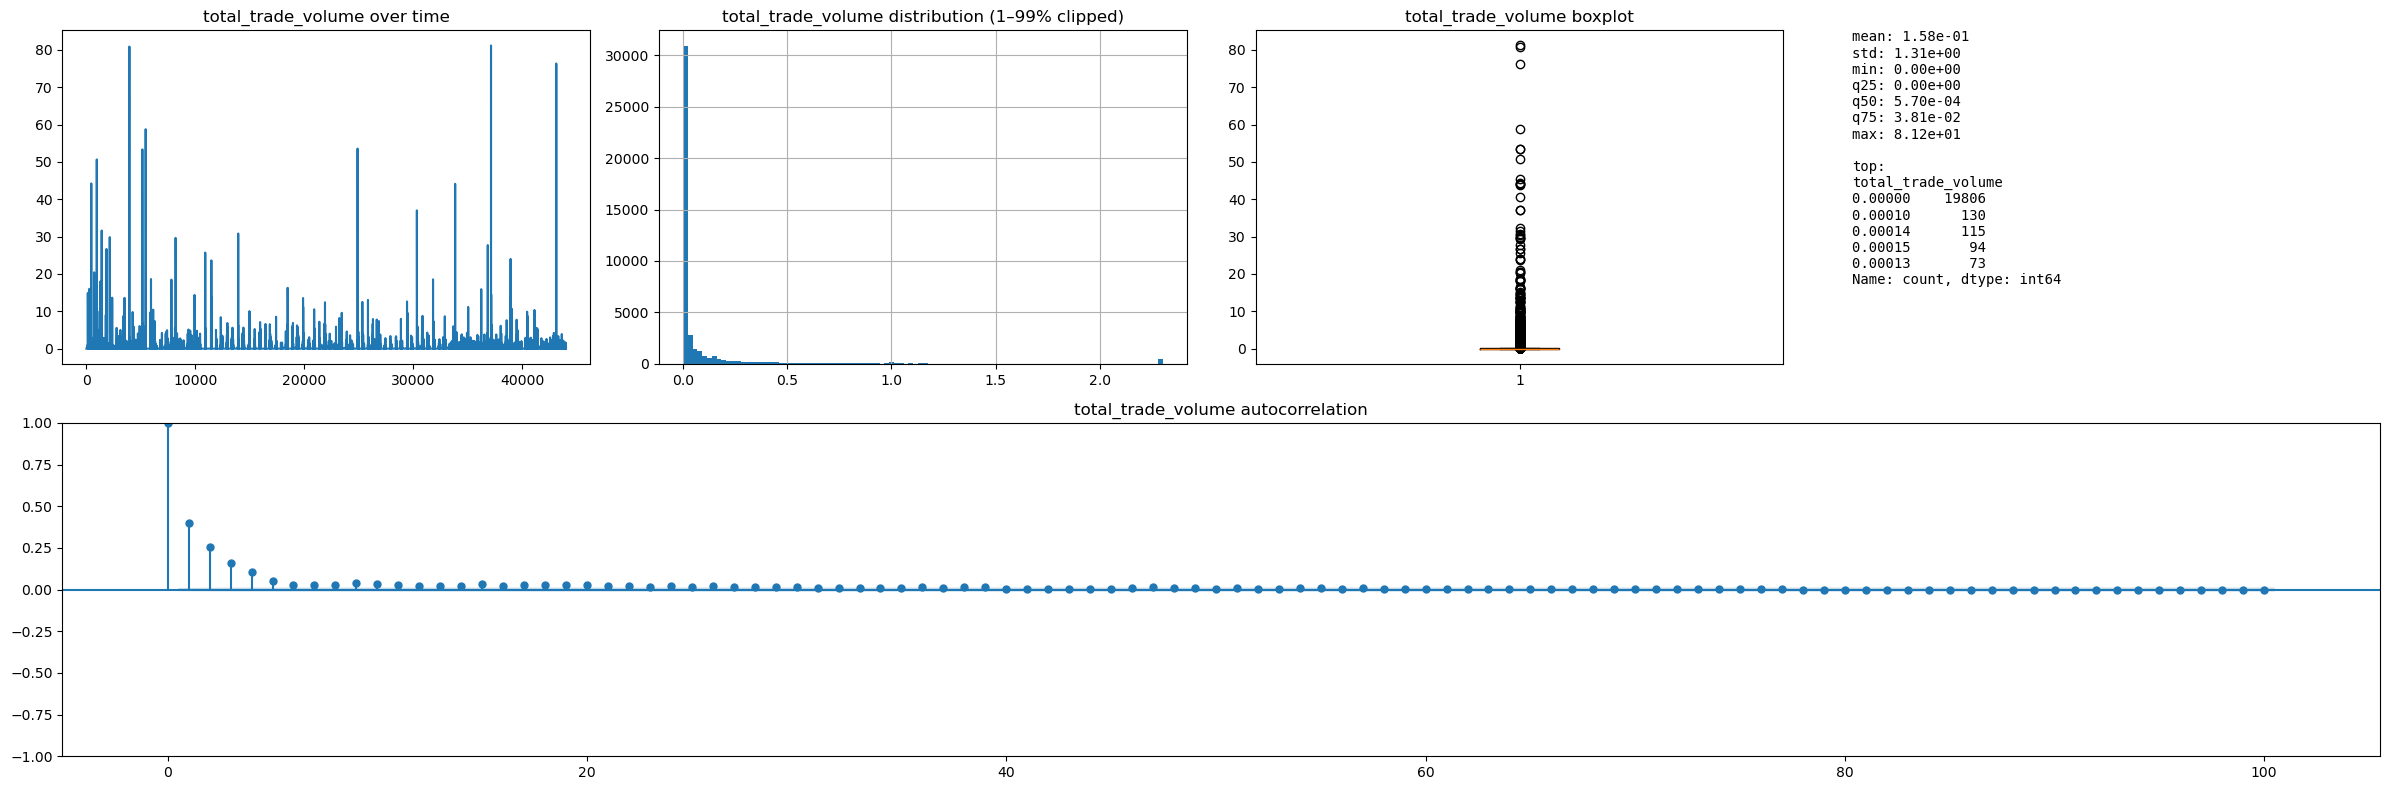

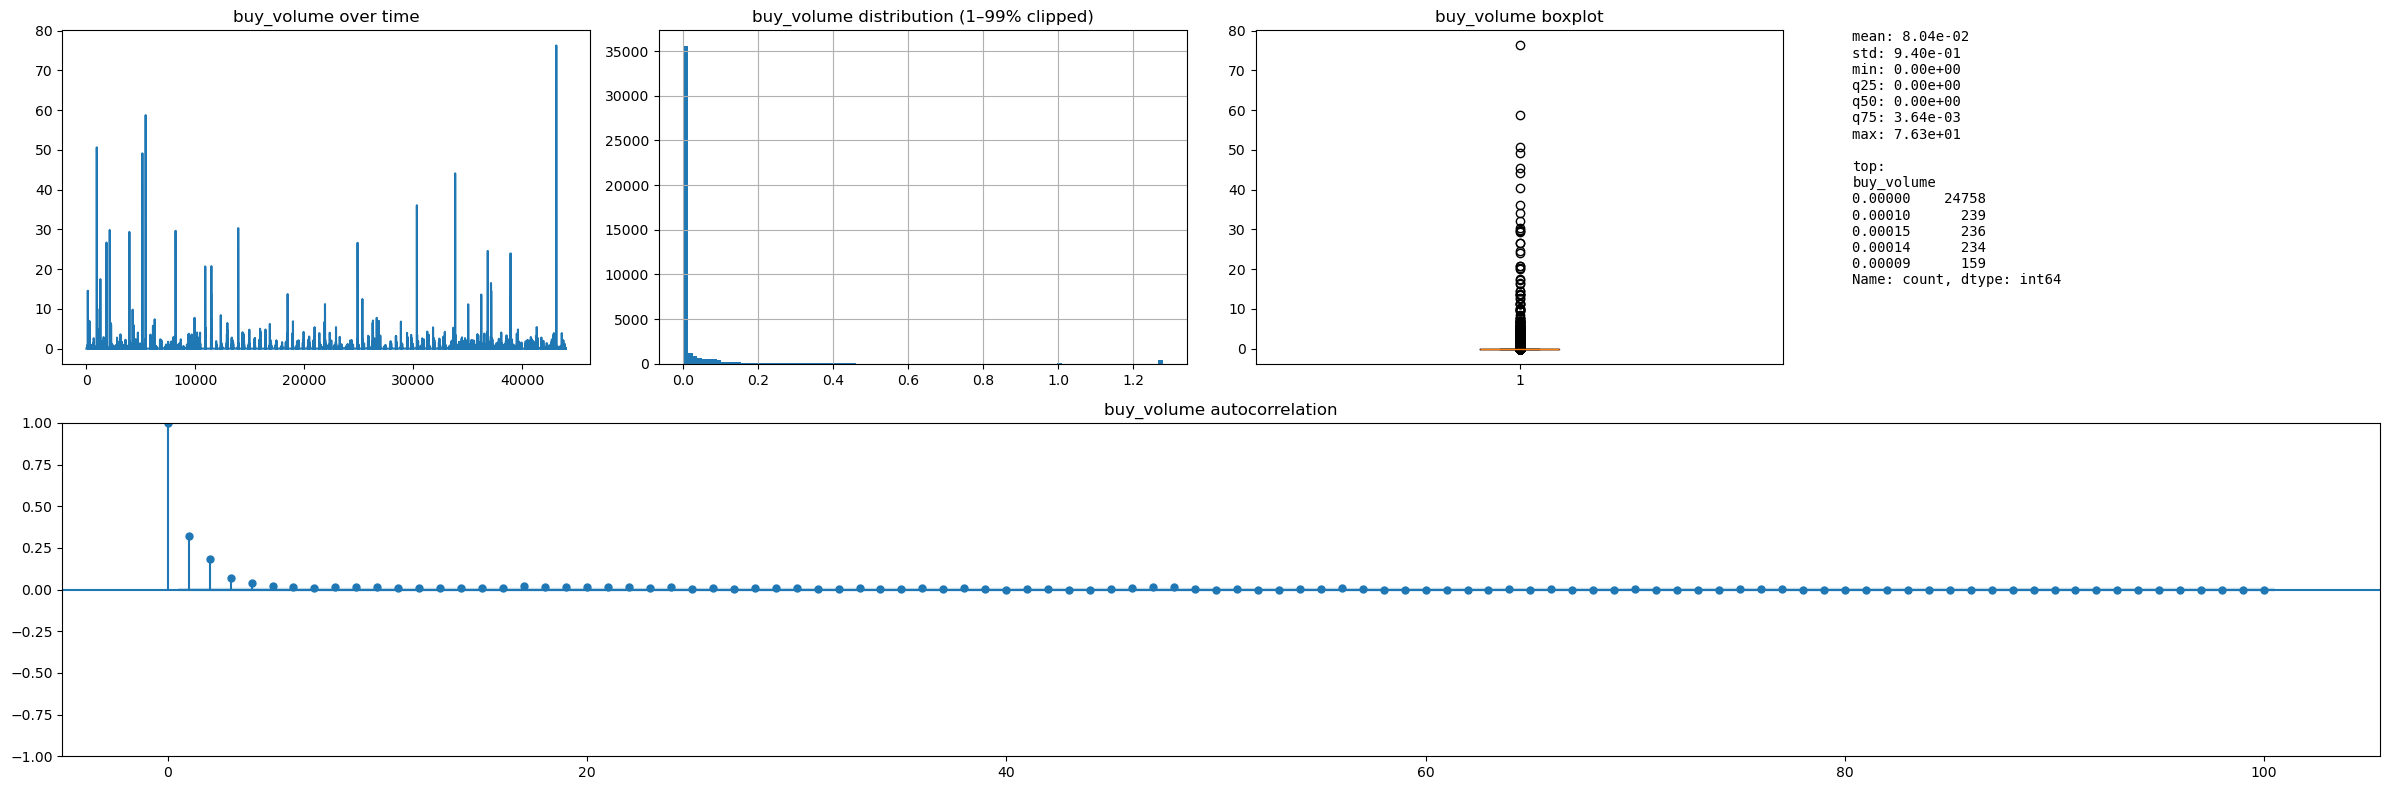

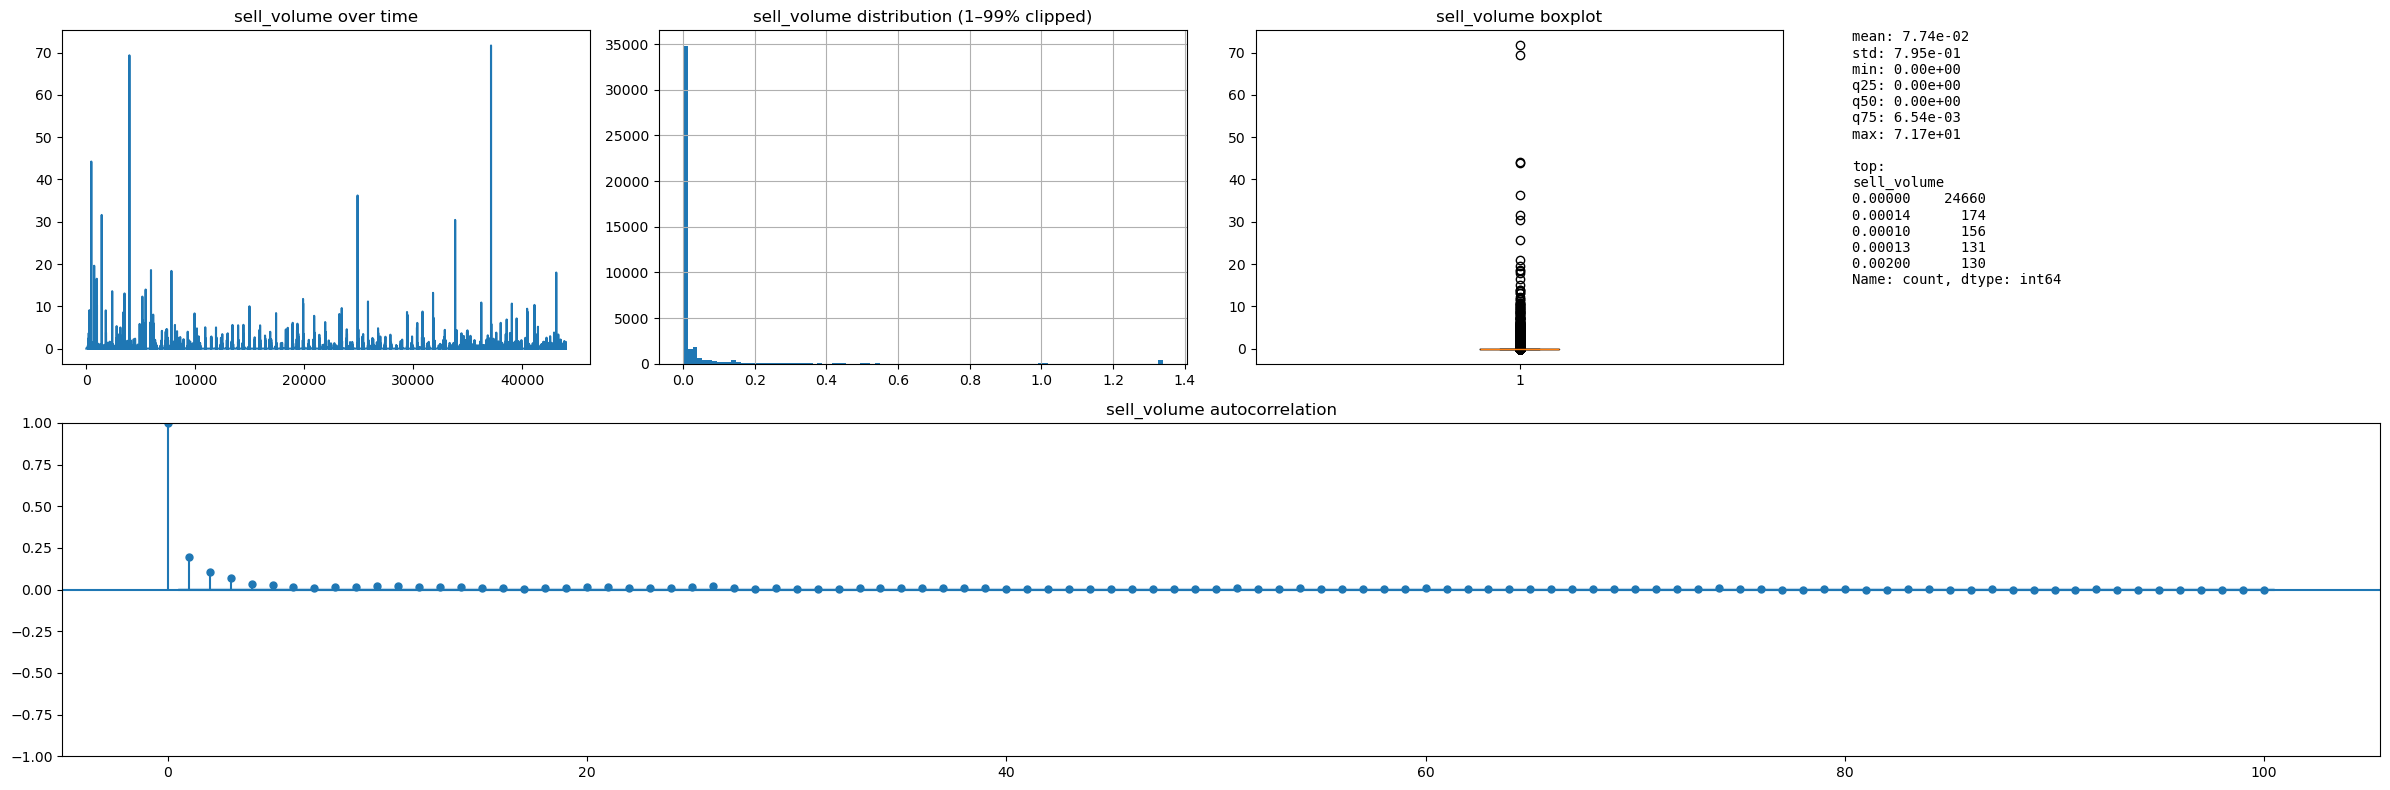

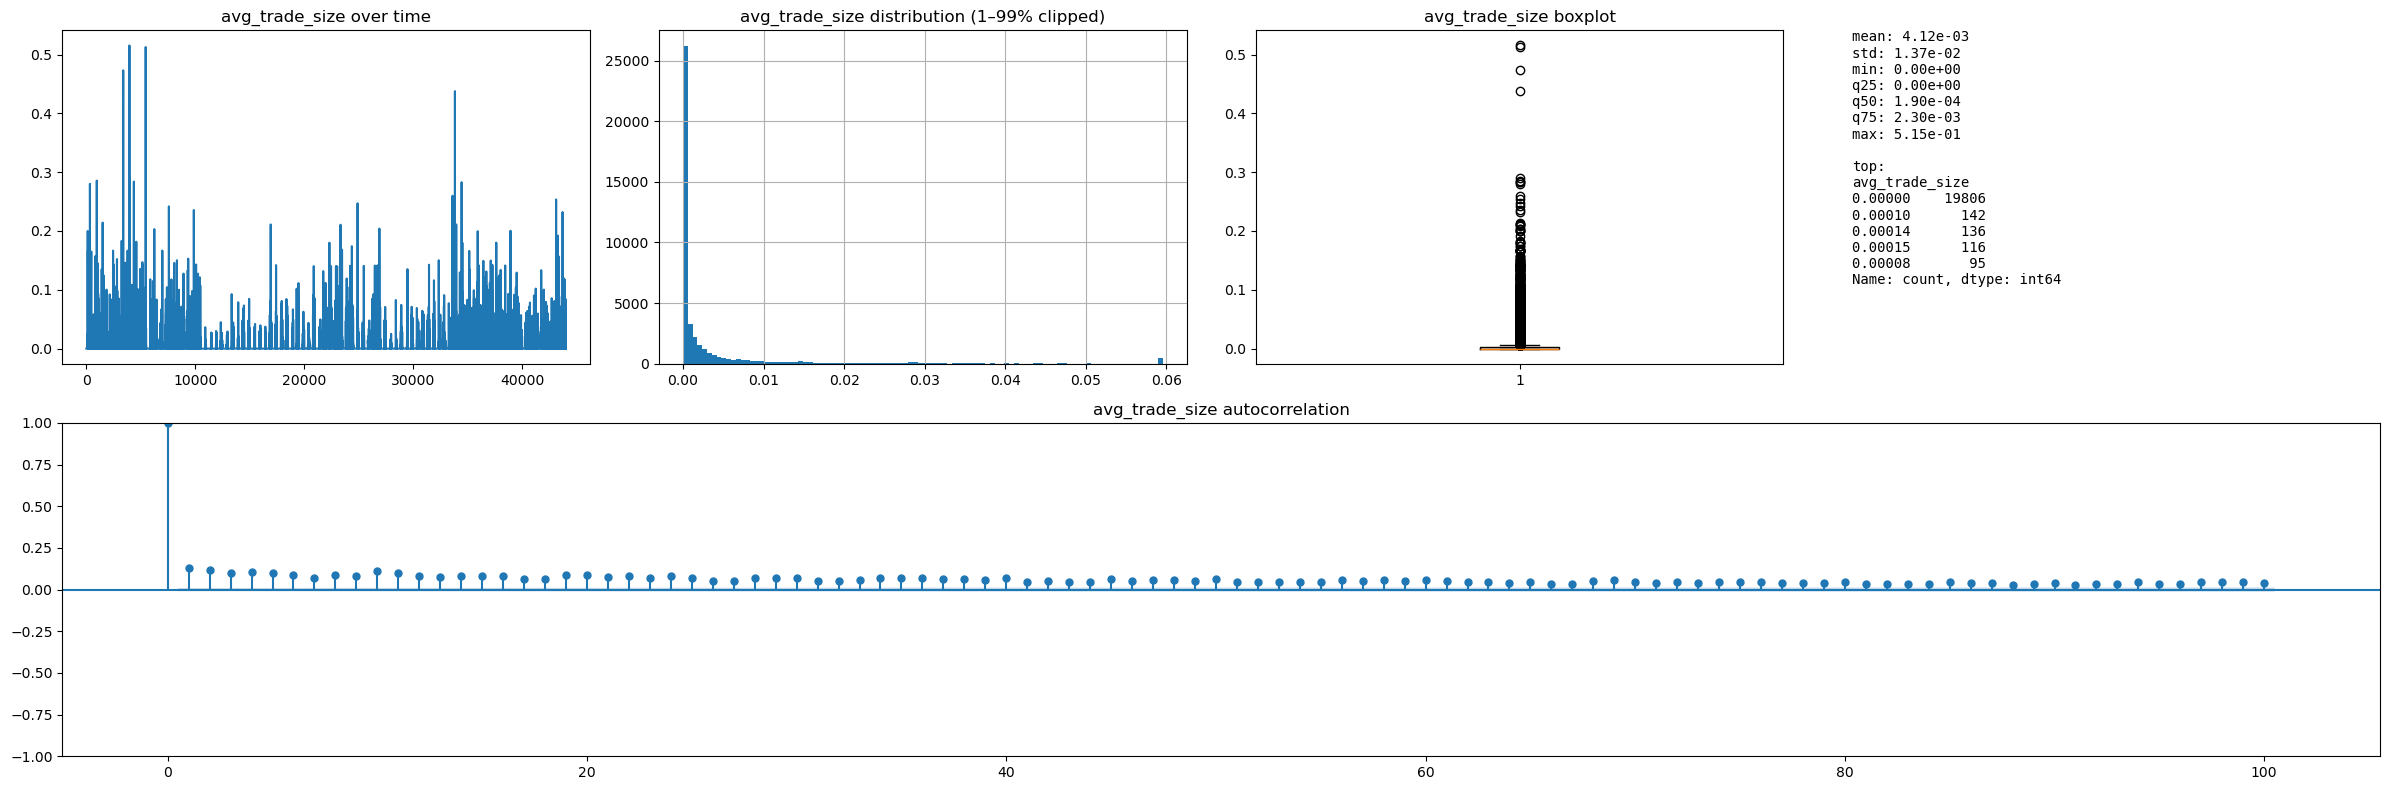

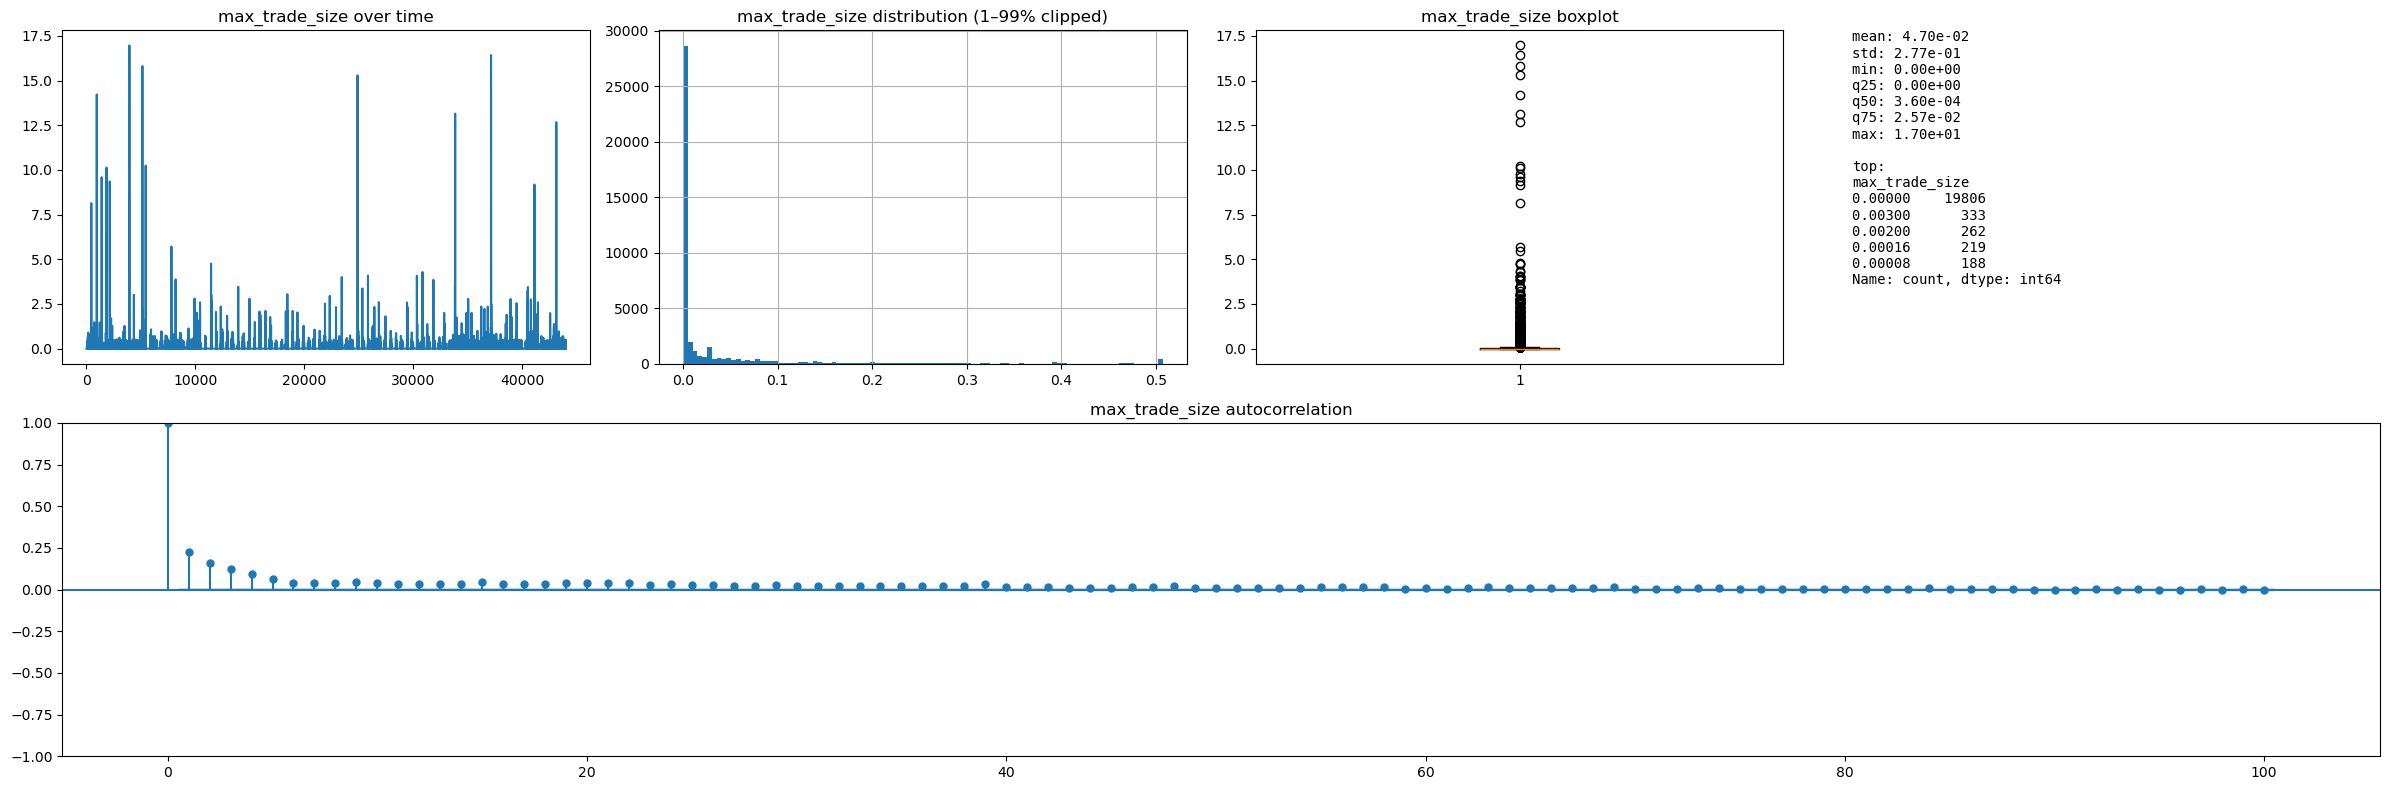

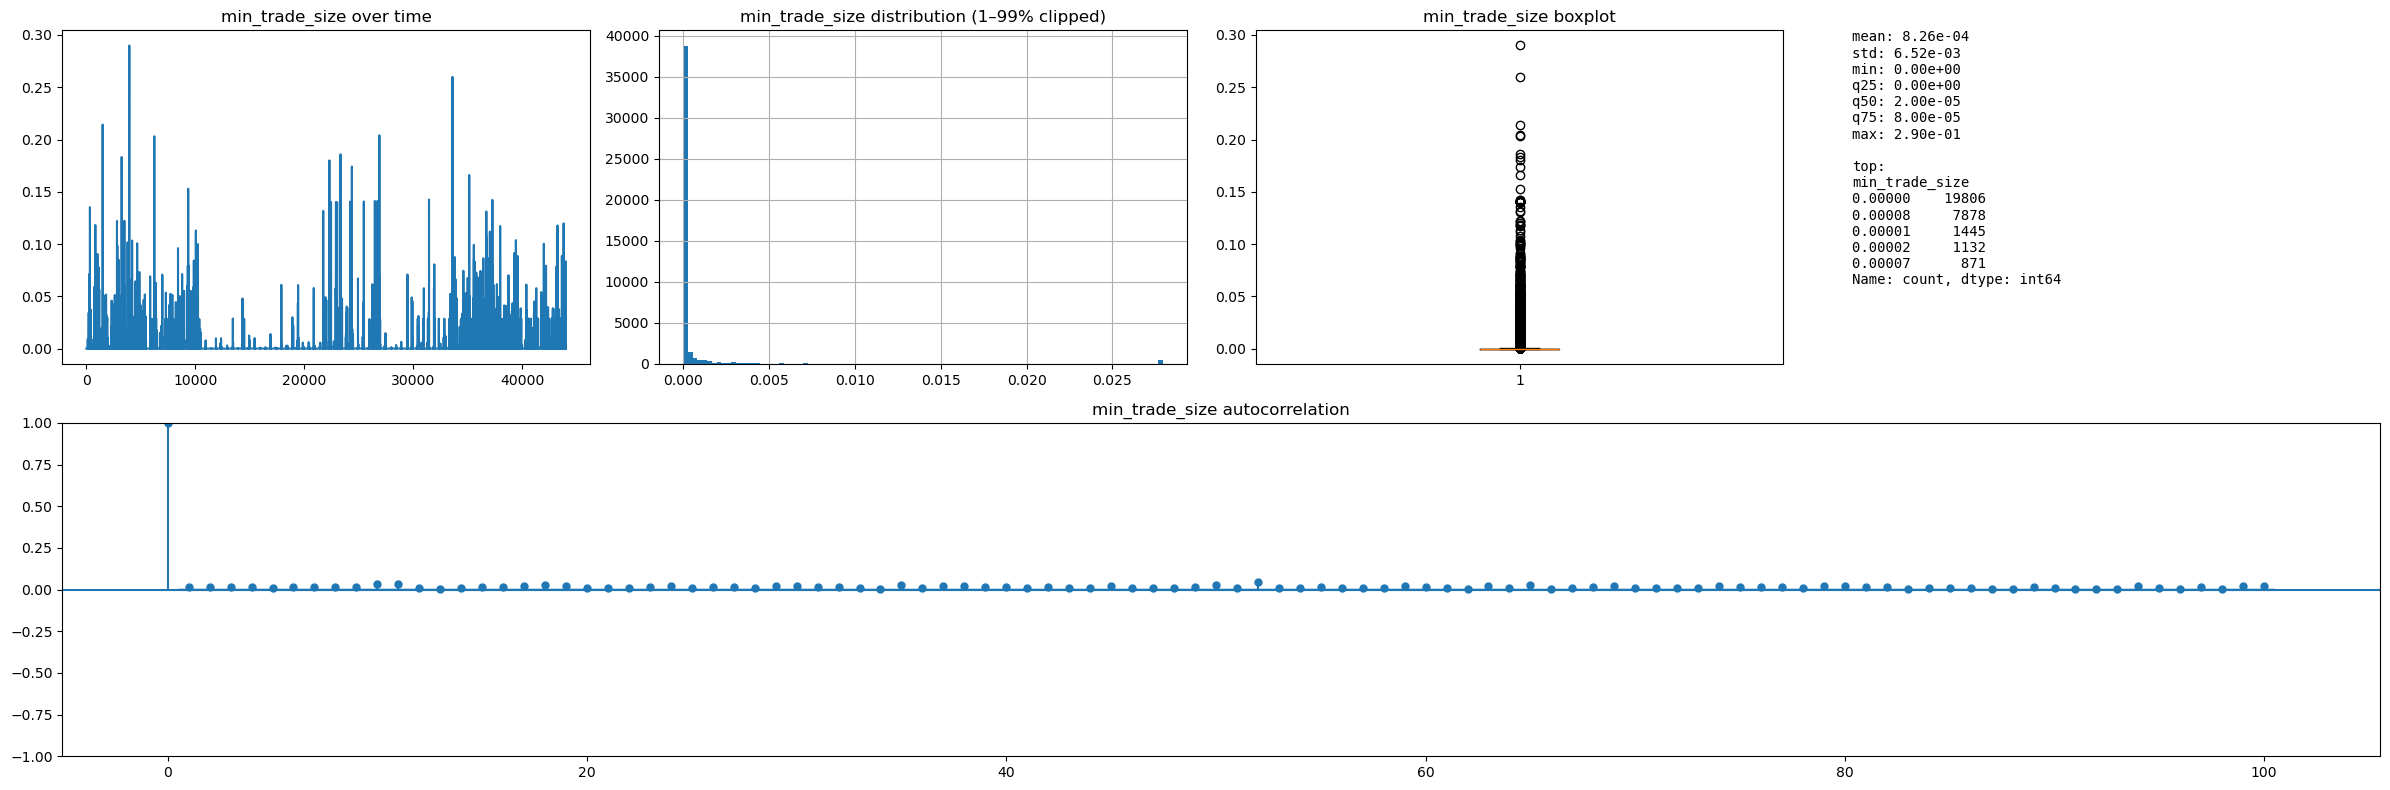

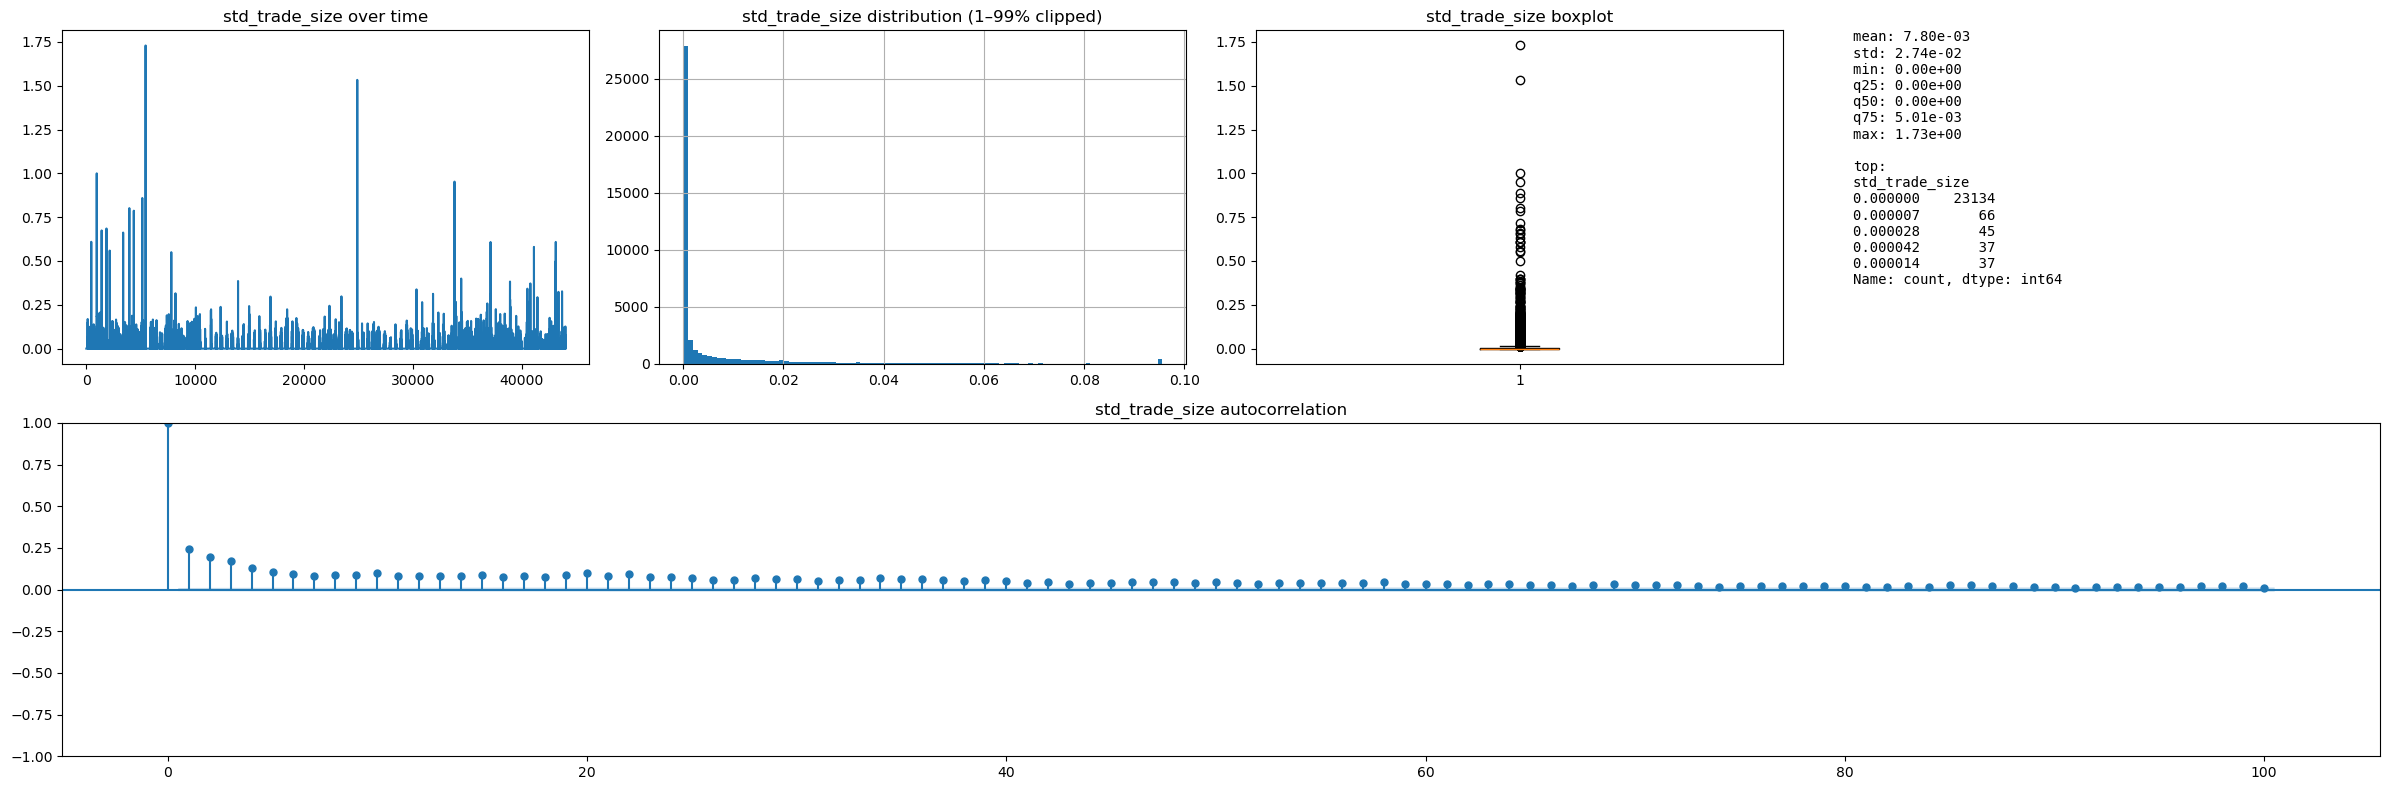

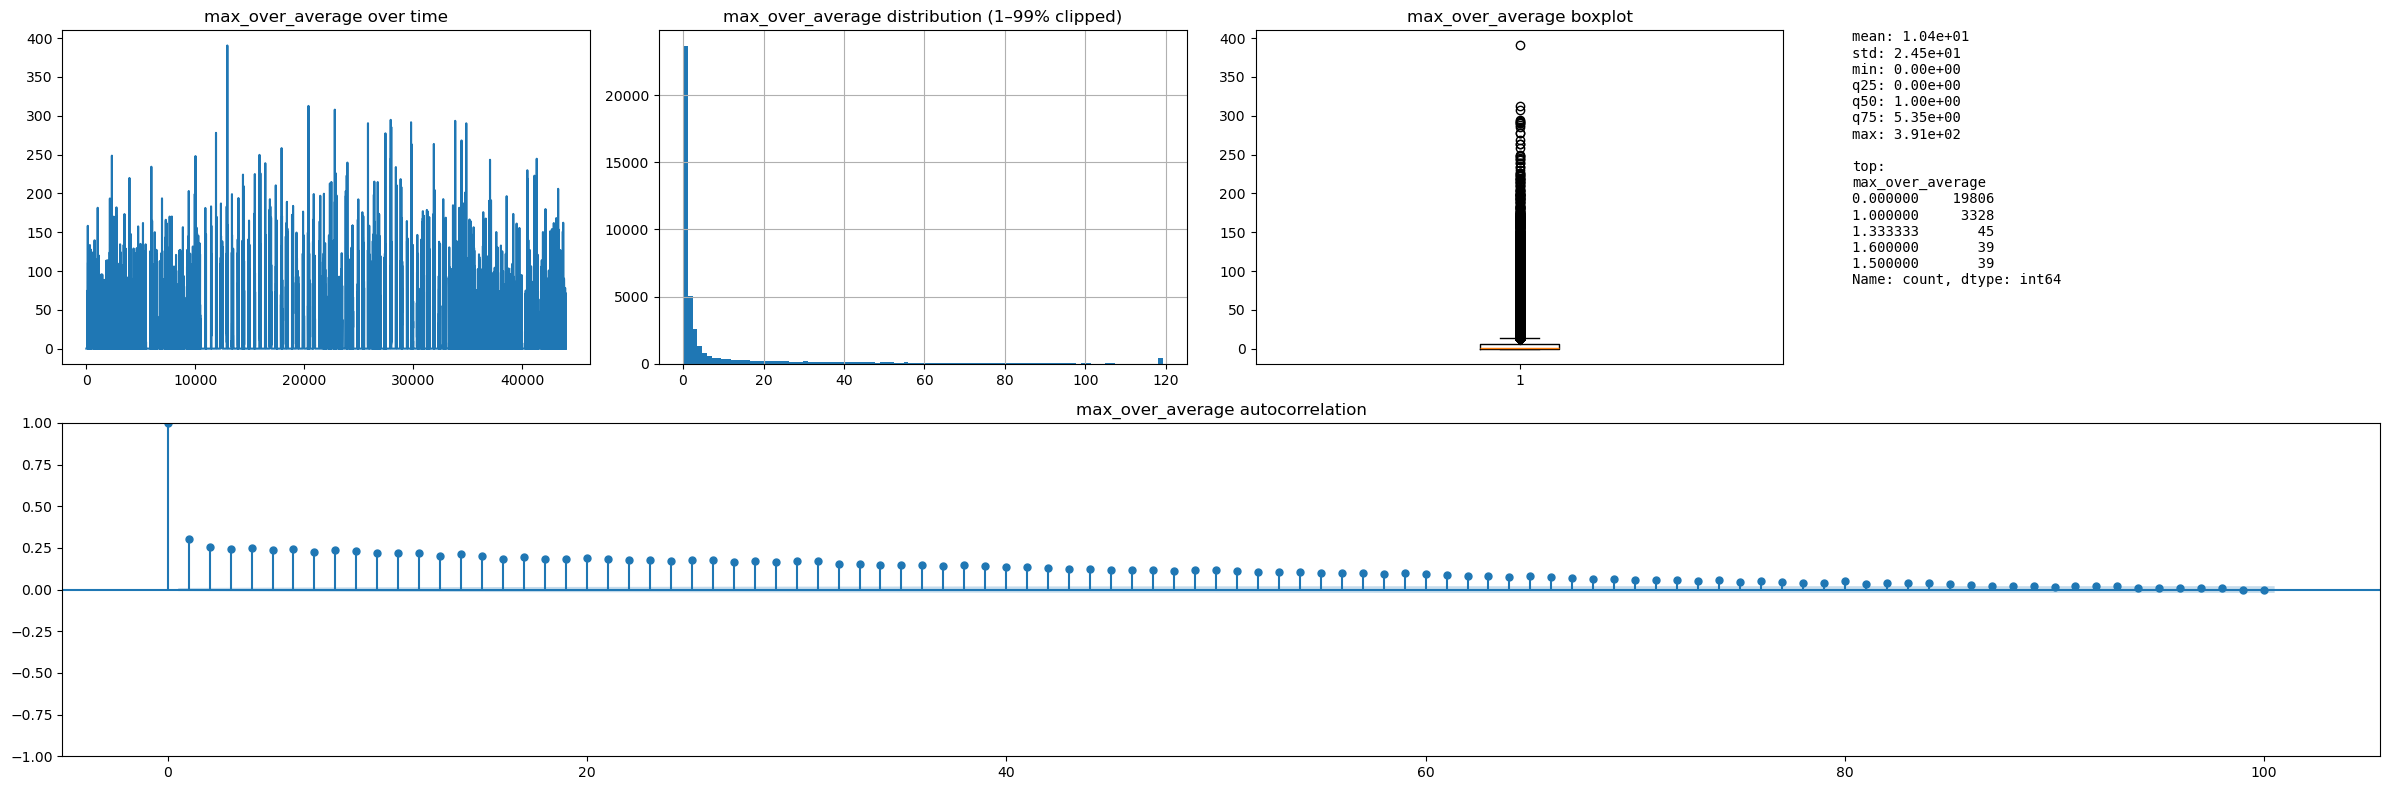

In [24]:
plotter_features(final_dataset, feature_groups["trade_volume"])

### Trade Volume

- Trade volume and buy/sell volumes are have long taisl
- Occasional large spikes indicate bursts of trading activity
- Also comparing to previous plots it seems like these short spikes are due to one or a few trades being for high volume rather than a big increase in demand from lots of small volume orders
- Trade size statistics show that most trades are small, while a few large trades create heavy tails in the distribution.

In [25]:
# plotter_features(final_dataset, feature_groups["trade_flow"])

### Trade Flow

- Trade volume imbalance spans the full range [-1, 1], showing periods dominated by either buy or sell pressure.
- The distribution has strong mass near the extremes, indicating many intervals with one-sided trading.
- Trade flow ratio is extremely skewed (due to some times the sell volume being zero therefore 1/epislon ~ 1e9)

In [26]:
# plotter_features(final_dataset, feature_groups["trade_dynamics"])

### Trade Dynamics

- Changes in trade volume and trade count fluctuate around zero
- Most changes are small, but occasional large spikes occur
- The distributions are heavy-tailed.

In [27]:
# plotter_features(final_dataset, feature_groups["lagged_trade"])

### Lagged Trade Flow

- Lagged trade imbalance has the same structure as the original imbalance but shifted in time.
- Values still cluster near +-1


# Feature vs target and feature choice

Need a way to calc uncertainty of each feature bin target mean value 



In [28]:
def block_bootstrap_sem(x, block_size=5, n_boot=100):
    x = np.asarray(x)
    n = len(x)
    means = []

    for _ in range(n_boot):
        sample = []

        while len(sample) < n:
            i = np.random.randint(0, n - block_size)
            sample.extend(x[i : i + block_size])

        sample = np.array(sample[:n])
        means.append(sample.mean())

    return np.std(means)

need to calculate autocorreltion lag

In [29]:
def conditional_expectation_plotter(df, features, target, block_size, boosts):
    num_plots = len(features)
    rows = math.ceil(num_plots / 3)
    size_of_features = len(features)
    columns = size_of_features if size_of_features < 3 else 3

    fig, ax = plt.subplots(rows, columns, figsize=(28, 6 * rows))
    ax = np.atleast_1d(ax).flatten()

    for i, feature in enumerate(features):

        bins = pd.qcut(df[feature], 10, duplicates="drop")
        grouped = df.groupby(bins)

        means = grouped[target].mean()
        sems = grouped[target].apply(
            lambda x: block_bootstrap_sem(x, block_size, boosts)
        )
        std = grouped[target].std()
        count = grouped[target].count()

        sem_naive = std / np.sqrt(count)

        # x values = mean feature value in each bin
        bin_means = grouped[feature].mean()
        offset = 0.01 * (bin_means.max() - bin_means.min())

        ax[i].errorbar(
            bin_means, means, yerr=sem_naive, capsize=3, marker="o", label="Naive SEM"
        )
        ax[i].set_title(feature)
        ax[i].set_xlabel(feature)
        ax[i].set_ylabel(target)

    plt.tight_layout()

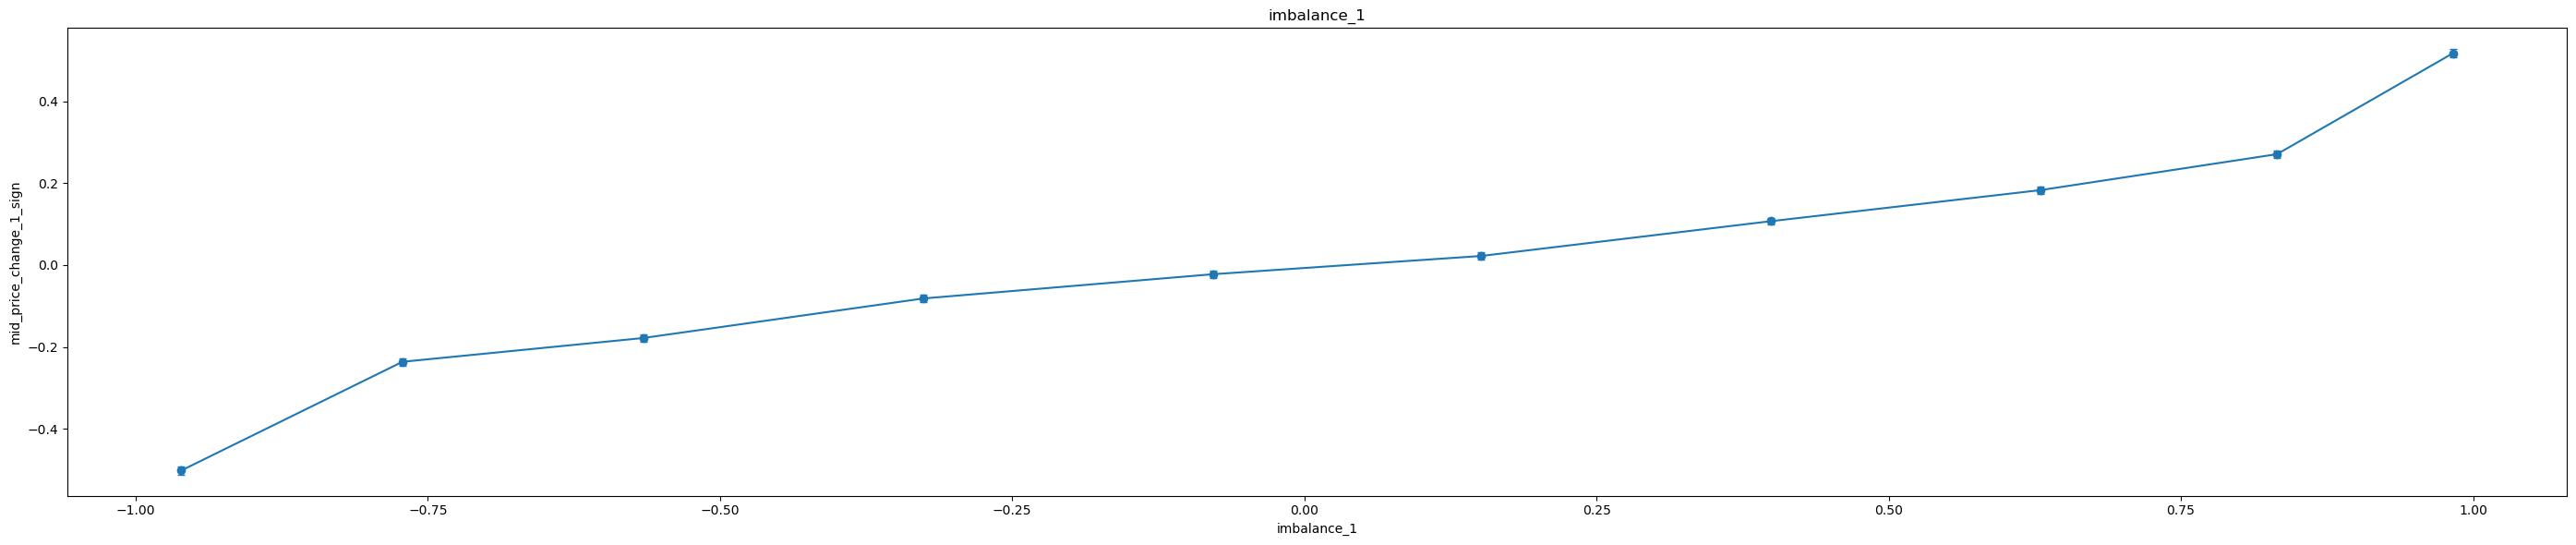

In [30]:
target = "mid_price_change_1_sign"
feature_groups_total = [
    feature for group in feature_groups.values() for feature in group
]
imbalance_plot = ["imbalance_1"]
conditional_expectation_plotter(final_dataset, imbalance_plot, target, 20, 100)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf


def compute_signal_autocorr(
    df,
    feature,
    target,
    n_bins=20,
    nlags=100,
    plot=True,
    ax=None,
):

    # --- 1. Bin feature
    bins = pd.qcut(df[feature], n_bins, duplicates="drop")

    # --- 2. Conditional expectation per bin
    bin_means = df.groupby(bins)[target].mean()

    # --- 3. Map to time series (signal)
    y_hat = bins.map(bin_means).astype(float).dropna()

    # --- 4. ACF
    acf_vals = acf(y_hat, nlags=nlags)

    # --- 5. Robust integrated tau (only positive lags)
    positive_acf = acf_vals[1:][acf_vals[1:] > 0]
    tau_int = 1 + 2 * np.sum(positive_acf)

    # --- 6. Cutoff tau
    below = np.where(acf_vals < 0.1)[0]
    tau_cutoff = below[0] if len(below) > 0 else nlags

    # --- 7. Effective sample size
    n_eff = len(y_hat) / tau_int if tau_int > 0 else np.nan

    # --- 8. Plot
    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 4))

        ax.plot(acf_vals, marker="o")
        ax.axhline(0, linestyle="--")
        ax.axvline(
            tau_cutoff, color="red", linestyle="--", label=f"cutoff τ={tau_cutoff}"
        )
        ax.set_title(f"Signal ACF: {feature}")
        ax.set_xlabel("Lag")
        ax.set_ylabel("ACF")
        ax.legend()

    return {
        "y_hat": y_hat,
        "acf": acf_vals,
        "tau_int": tau_int,
        "tau_cutoff": tau_cutoff,
        "n_eff": n_eff,
    }

9.59691179937921 4584.7040089340135


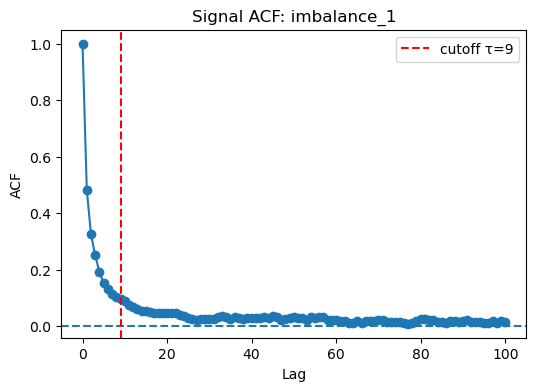

In [32]:
res = compute_signal_autocorr(final_dataset, "imbalance_1", target)

print(res["tau_int"], res["n_eff"])

I want to choose a constant block size across all features to make comparing easier and pipeline easier

to do thisi will look at some of the commonly good features and decide a block size that covers them all

In [33]:
tau_features = [
    "imbalance_1",
    "imbalance_5",
    "imbalance_10",
    "trade_volume_imbalance",
    "buy_count",
    "sell_count",
    "mid_minus_micro",
    "microprice_change",
    "log_return_1",
    "mid_price_change_1",
    # new ones
    "trade_count",
    "trade_volume_change",
    "trade_count_change",
    "vol_5",
    "realized_vol_5",
    "log_return_2",
    "log_return_3",
    "lag_trade_volume_imbalance_1",
    "lag_trade_volume_imbalance_2",
]

In [34]:
features = tau_features  # your selected list

n = len(features)
cols = 3
rows = int(np.ceil(n / cols))
list_of_cutoffs = []
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, f in enumerate(features):
    res = compute_signal_autocorr(
        final_dataset,
        feature=f,
        target=target,
        ax=axes[i],
        plot=True,
    )
    list_of_cutoffs.append(res["tau_cutoff"])

# remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.close(fig)
# plt.tight_layout()
# plt.show()
print(np.max(list_of_cutoffs))

19


will choose 10 as the blcok size for target of mid_price_1

Making scoring table for each var

In [35]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


def feature_scoring(df, feature, target, ax=None):

    bins = pd.qcut(df[feature], 10, duplicates="drop")
    grouped = df.groupby(bins)
    means = grouped[target].mean()
    count = grouped[target].count()
    sems = grouped[target].apply(lambda x: block_bootstrap_sem(x, 10, 100))

    bin_means = grouped[feature].mean()

    x_vals = bin_means.values.reshape(-1, 1)
    y_vals = means.values
    reg_weights = 1 / (sems**2)
    model = LinearRegression().fit(x_vals, y_vals, sample_weight=reg_weights)
    y_pred = model.predict(x_vals)
    residuals = y_vals - y_pred
    non_lin_score = np.mean((residuals / sems) ** 2)

    # feature stats
    weight_bin = count / count.sum()
    signal_strength = (means.abs() * weight_bin).sum()
    s_over_noise_weighted = ((means.abs() / sems) * weight_bin).sum()

    # stability
    stability = ((means.abs() > sems) * weight_bin).sum()

    return {
        "feature": feature,
        "signal_strength": signal_strength,
        "s_over_noise_weighted": s_over_noise_weighted,
        "nonlinearity": non_lin_score,
        "stability": stability,
    }

In [36]:
feature_groups_total = [
    feature for group in feature_groups.values() for feature in group
]
feature_groups_total = list(set(feature_groups_total))

In [37]:
results = []

for feature in feature_groups_total:
    try:
        res = feature_scoring(final_dataset, feature, target)
        results.append(res)
    except Exception:
        continue

feature_df = pd.DataFrame(results)

feature_df = feature_df[~feature_df["feature"].str.contains("mid_price_change")]

feature_df = feature_df[feature_df["feature"] != "spread"]

In [38]:
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.4f}".format)
feature_df = feature_df.sort_values(
    by="s_over_noise_weighted", ascending=False
).reset_index(drop=True)
feature_df = feature_df.reset_index(drop=True)

feature_df.head(200)

,feature,signal_strength,s_over_noise_weighted,nonlinearity,stability
0,imbalance_5,0.2114,21.7197,56.6298,1.0000
1,imbalance_depth_1,0.2119,21.1899,51.8184,1.0000
2,imbalance_1,0.2119,20.8374,49.7189,1.0000
3,imbalance_10,0.2089,20.7187,49.1783,1.0000
4,max_bid_ask_vol_ratio,0.2119,20.2983,399.7419,1.0000
5,lob_asks_volume_1,0.2035,19.8533,153.6065,1.0000
6,total_ask_volume_10,0.2063,19.6496,193.3099,1.0000
7,total_bid_volume_10,0.1986,19.4744,160.2852,1.0000
8,mid_minus_micro,0.2120,18.9198,17.1940,1.0000
9,lob_bids_volume_1,0.1958,18.6462,159.4783,1.0000


In [39]:
feature_df = feature_df[feature_df["stability"] > 0.55]
feature_df = feature_df[feature_df["s_over_noise_weighted"] > 2]
feature_df

,feature,signal_strength,s_over_noise_weighted,nonlinearity,stability
0,imbalance_5,0.2114,21.7197,56.6298,1.0000
1,imbalance_depth_1,0.2119,21.1899,51.8184,1.0000
2,imbalance_1,0.2119,20.8374,49.7189,1.0000
3,imbalance_10,0.2089,20.7187,49.1783,1.0000
4,max_bid_ask_vol_ratio,0.2119,20.2983,399.7419,1.0000
5,lob_asks_volume_1,0.2035,19.8533,153.6065,1.0000
6,total_ask_volume_10,0.2063,19.6496,193.3099,1.0000
7,total_bid_volume_10,0.1986,19.4744,160.2852,1.0000
8,mid_minus_micro,0.2120,18.9198,17.1940,1.0000
9,lob_bids_volume_1,0.1958,18.6462,159.4783,1.0000


Remove raw features and then look at correlation between variables

correlation is okay if the underlying economic reasoning is different


['imbalance_5', 'imbalance_depth_1', 'imbalance_1', 'imbalance_10', 'max_bid_ask_vol_ratio', 'lob_asks_volume_1', 'total_ask_volume_10', 'total_bid_volume_10', 'mid_minus_micro', 'lob_bids_volume_1', 'lob_asks_volume_2', 'lob_asks_volume_3', 'microprice_change', 'sell_count', 'lob_asks_volume_4', 'lob_asks_volume_5', 'buy_count', 'imbalance_depth_3', 'lob_asks_volume_7', 'lob_bids_volume_2', 'log_depth_ratio_3', 'lob_bids_volume_3', 'imbalance_depth_4', 'log_depth_ratio_4', 'lob_asks_volume_6', 'lob_bids_volume_4', 'lob_asks_volume_8', 'log_return_2', 'imbalance_depth_2', 'log_depth_ratio_2', 'imbalance_depth_5', 'lob_bids_volume_5', 'lob_bids_volume_6', 'lob_asks_volume_9', 'sell_volume', 'log_depth_ratio_5', 'imbalance_depth_6', 'log_depth_ratio_7', 'log_depth_ratio_6', 'lob_bids_volume_7', 'lob_asks_volume_10', 'lob_bids_volume_8', 'imbalance_depth_7', 'buy_volume', 'lob_bids_volume_9', 'imbalance_depth_9', 'imbalance_depth_8', 'imbalance_depth_10', 'log_depth_ratio_9', 'log_return_

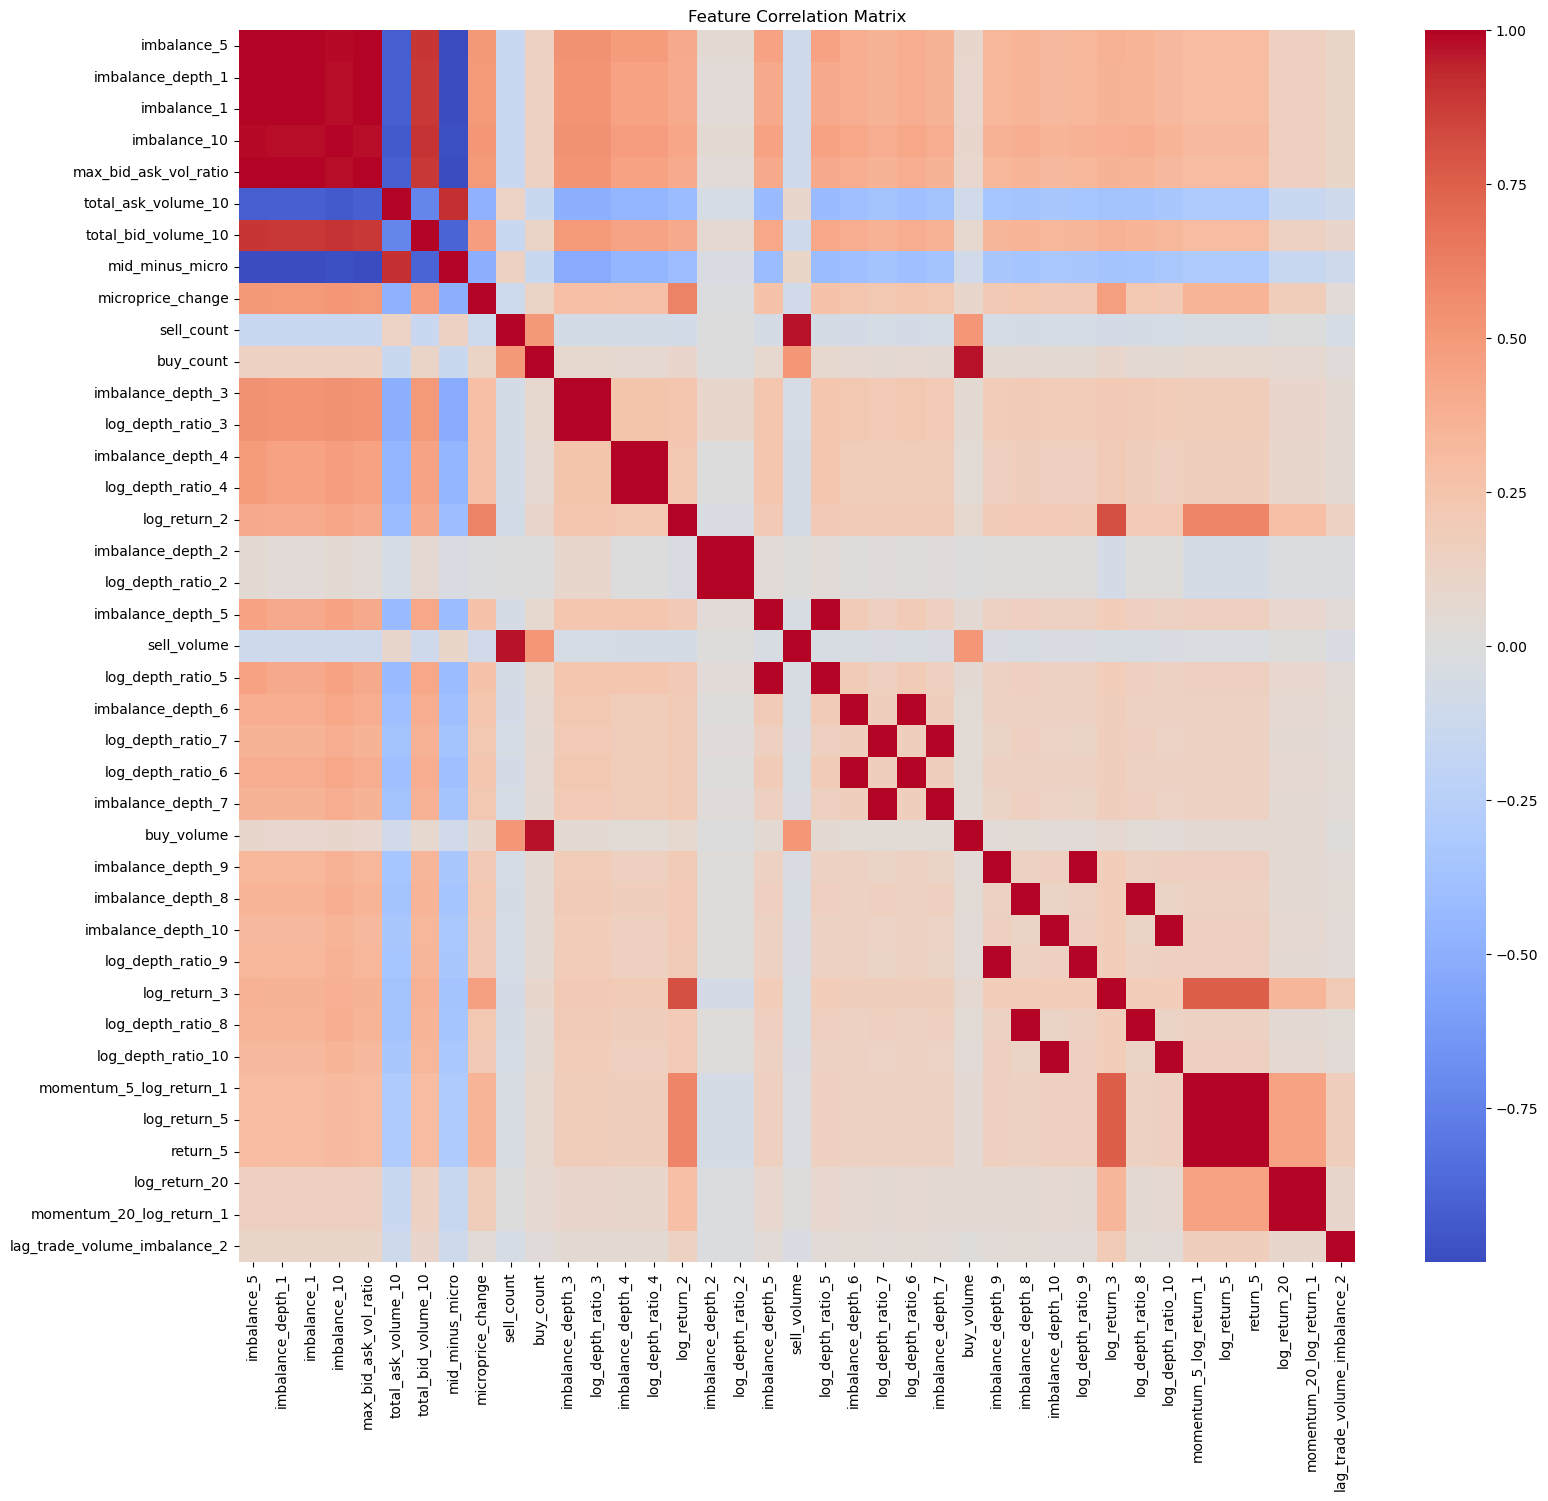

In [40]:
features = feature_df["feature"].tolist()
print(features)
features = [f for f in features if not f.startswith("lob_bids_volume_")]
features = [f for f in features if not f.startswith("lob_asks_volume_")]
data = final_dataset[features]  # <-- NOT feature_df
print(features)

corr = data.corr(method="spearman")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 16))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [41]:
threshold = 0.9

selected = []
clusters = {}

for f in features:  # already sorted by score
    assigned = False

    for s in selected:
        if abs(corr[f][s]) >= threshold:
            clusters[s].append(f)
            assigned = True
            break

    if not assigned:
        selected.append(f)
        clusters[f] = []  # initialise cluster

In [42]:
selected

['imbalance_5',
 'total_bid_volume_10',
 'microprice_change',
 'sell_count',
 'buy_count',
 'imbalance_depth_3',
 'imbalance_depth_4',
 'log_return_2',
 'imbalance_depth_2',
 'imbalance_depth_5',
 'imbalance_depth_6',
 'log_depth_ratio_7',
 'imbalance_depth_9',
 'imbalance_depth_8',
 'imbalance_depth_10',
 'log_return_3',
 'momentum_5_log_return_1',
 'log_return_20',
 'lag_trade_volume_imbalance_2']

In [43]:
clusters

{'imbalance_5': ['imbalance_depth_1',
  'imbalance_1',
  'imbalance_10',
  'max_bid_ask_vol_ratio',
  'total_ask_volume_10',
  'mid_minus_micro'],
 'total_bid_volume_10': [],
 'microprice_change': [],
 'sell_count': ['sell_volume'],
 'buy_count': ['buy_volume'],
 'imbalance_depth_3': ['log_depth_ratio_3'],
 'imbalance_depth_4': ['log_depth_ratio_4'],
 'log_return_2': [],
 'imbalance_depth_2': ['log_depth_ratio_2'],
 'imbalance_depth_5': ['log_depth_ratio_5'],
 'imbalance_depth_6': ['log_depth_ratio_6'],
 'log_depth_ratio_7': ['imbalance_depth_7'],
 'imbalance_depth_9': ['log_depth_ratio_9'],
 'imbalance_depth_8': ['log_depth_ratio_8'],
 'imbalance_depth_10': ['log_depth_ratio_10'],
 'log_return_3': [],
 'momentum_5_log_return_1': ['log_return_5', 'return_5'],
 'log_return_20': ['momentum_20_log_return_1'],
 'lag_trade_volume_imbalance_2': []}

# using economical reasoning + correlationd decide features

In [44]:
final_feature_list = [
    "trade_volume_imbalance",
    "lag_trade_volume_imbalance_1",
    "imbalance_1",
    "log_depth_ratio_3",
    "log_depth_ratio_5",
    "mid_minus_micro",
    "microprice_change",
    "log_return_1",
    "log_return_2",
    "log_return_3",
    "log_return_5",
    "imbalance_5"
]

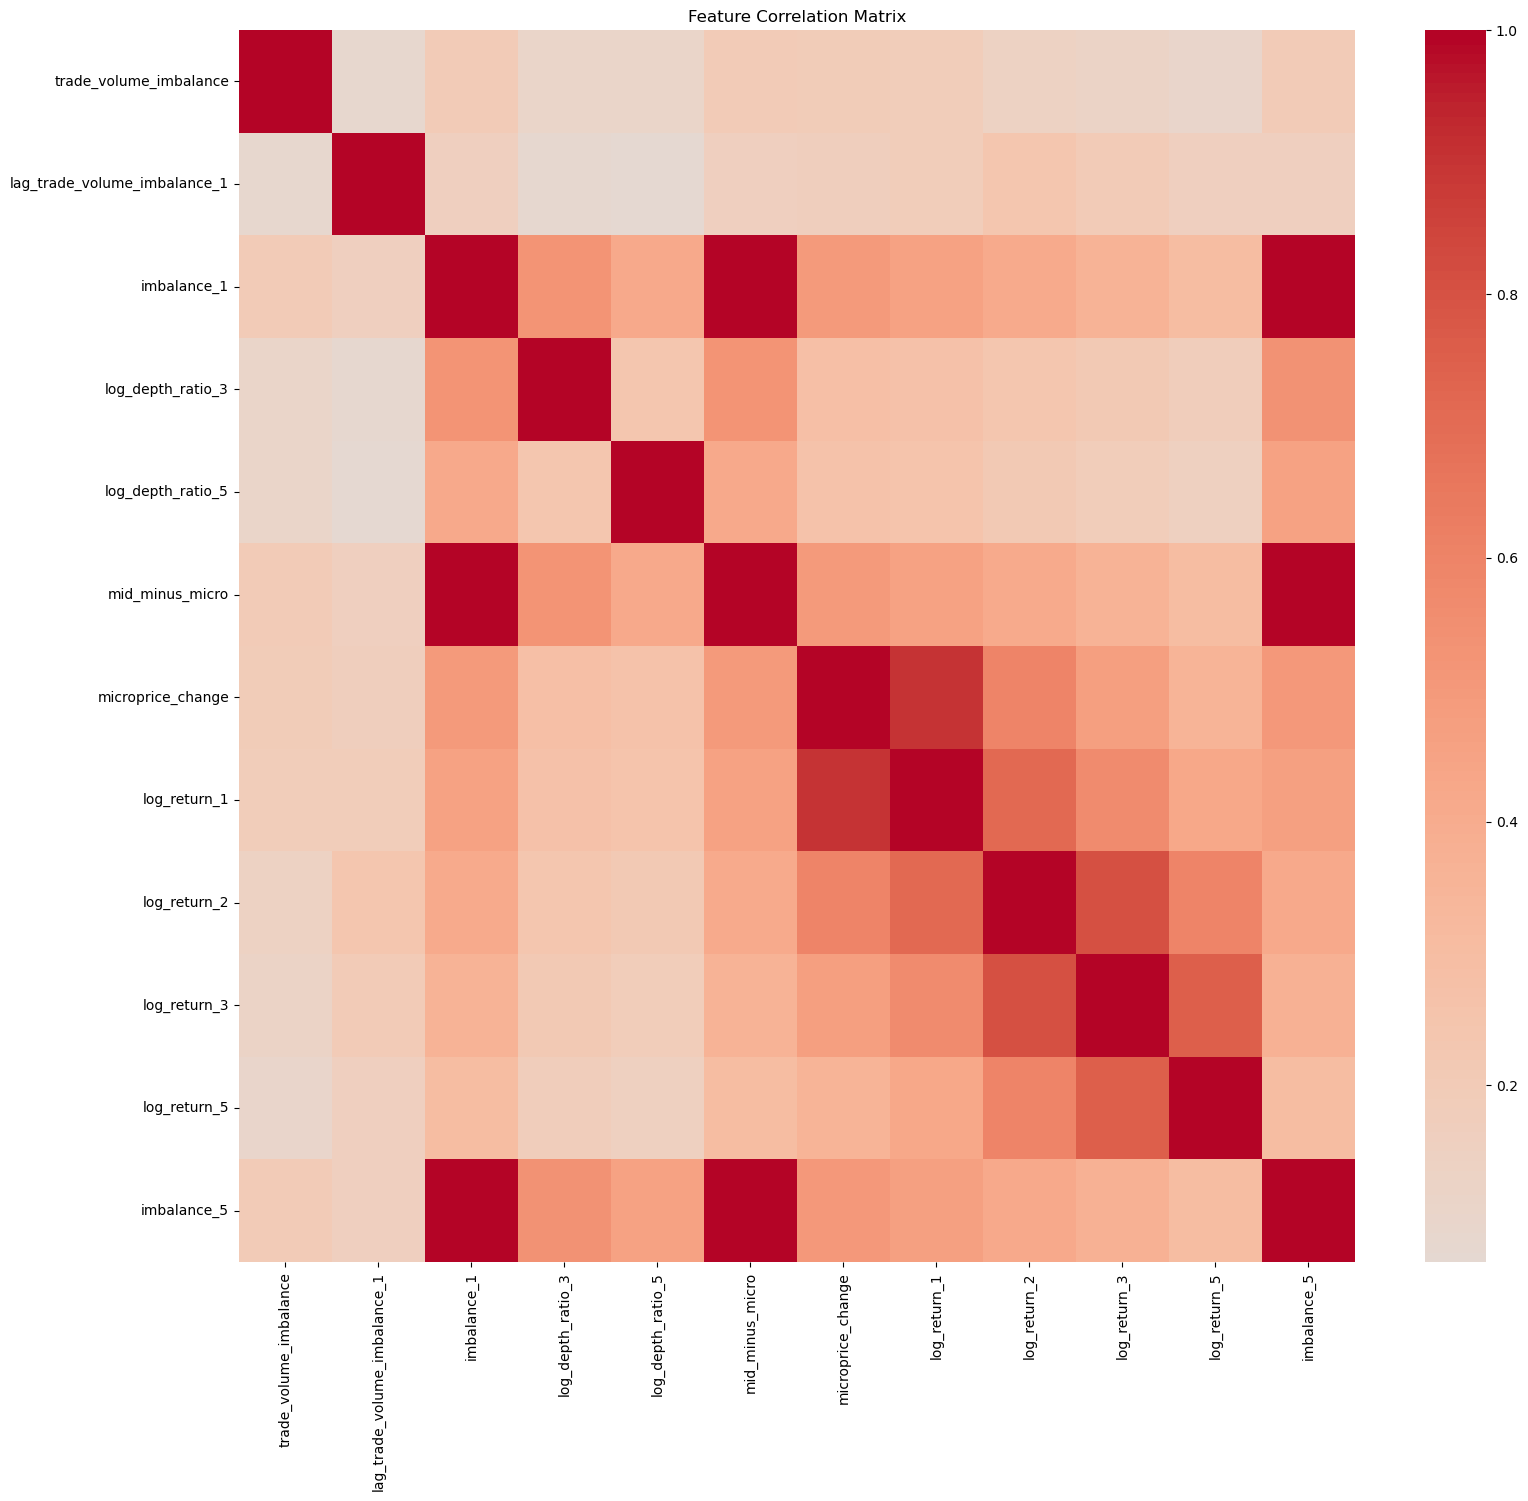

In [45]:
data = final_dataset[final_feature_list]
corr = data.corr(method="spearman")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 16))
sns.heatmap(abs(corr), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()
